# NYC 2027 Executive Budget Extraction


## Pdfplumber


### Imports


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import camelot
import pdfplumber
import re
from pathlib import Path
from tqdm.auto import tqdm


from IPython.display import display

### Functions and Constants


In [4]:
ROOT_DIR = Path.cwd()
DOCS_DIR = ROOT_DIR / "Docs"
print(f"ROOT_DIR: {ROOT_DIR}")
print(f"DOCS_DIR: {DOCS_DIR}")

ROOT_DIR: /Users/vuhepola/Library/CloudStorage/Box-Box/3. NYU/25-26/Spring 2026/Burke Proj/NYC/Python
DOCS_DIR: /Users/vuhepola/Library/CloudStorage/Box-Box/3. NYU/25-26/Spring 2026/Burke Proj/NYC/Python/Docs


In [5]:
doc_name = "5_26_expense_only.pdf"
doc_path = DOCS_DIR/ doc_name

print(f"DOCS_DIR/ doc_name: {doc_path}")

DOCS_DIR/ doc_name: /Users/vuhepola/Library/CloudStorage/Box-Box/3. NYU/25-26/Spring 2026/Burke Proj/NYC/Python/Docs/5_26_expense_only.pdf


In [6]:
VERSION = 3

In [7]:
COL_NAMES = [
    "FY2026 Adopted Budget",
    "FY2026 Modified Full-Time Positions",
    "FY2026 Modified Appropriation",
    "FY2026 Modified Change from Adopted",
    "FY2027 Executive Full-Time Positions",
    "FY2027 Executive Appropriation",
    "FY2027 Executive Change from Modified",
]
    
HARDCODED_BOUNDARIES = [
    188,  # Left edge of Adopted Budget 2026
    245,  # Right edge of Adopted Budget 2026
    273,  # Right edge of Mod: Full-Time Positions 2026
    334,  # Right edge of Mod: Appropriation 2026
    399,  # Right edge of Mod: Change From Adopted 2026
    430,  # Right edge of Exec: Full-Time Positions 2027
    488,  # Right edge of Exec: Appropriation 2027
    560,  # Right edge of Exec: Change From Adopted 2027
]

COLORS=[
    "black","red","orange","brown","green","blue","indigo","violet"
]

In [8]:
def extract_agency(document_path, page_number = 0):
    """
    Extracts Agency name and number from a PDF document at the desired page.
    """
    
    extracted_data = []

    with pdfplumber.open(document_path) as pdf:
        # Grab the first page (index 0)
        page = pdf.pages[page_number]
        
        # layout=True forces pdfplumber to reconstruct the visual line
        text = page.extract_text(layout=True)
        # print(text)
        
        pattern = re.compile(r"={132}\s+((?:[A-Za-z0-9_&\-'\s#.])+)\s+(\d{3})\s+(?:\(CONT\.\))?\s*(AGENCY EXPENSE BUDGET SUMMARY)\s+={132}", re.IGNORECASE)
        
        # Find all matching lines in the text
        raw_lines = pattern.findall(text)
        
        for line in raw_lines:
            # print(f"Captured Raw Line: {line}")
            # print(f"Length: {len(line)}")
            
            line = [l.strip() for l in line]
            
            # print(f"whitepsace striped: {line}")
            
            extracted_data.append(line)
            
            
    return extracted_data

page_list = [339]
with pdfplumber.open(doc_path) as pdf:
    for page_num in page_list:
        page = pdf.pages[page_num]        
        agency_data = extract_agency(doc_path, page_number = page_num)
        print(f"agency_data: {agency_data}")

agency_data: [['DEPARTMENT OF ENVIRONMENTAL PROTECT.', '826', 'AGENCY EXPENSE BUDGET SUMMARY']]


In [9]:
def assign_to_column(bbox_x0, boundaries):
    """Sorts the token's starting x0 position into your hardcoded buckets."""
    
    for i in range(7):
        if boundaries[i] <= bbox_x0 < boundaries[i+1]:
            return COL_NAMES[i]
            
    return None

Using bounding boxes


In [10]:
HARDCODED_BOUNDARIES = [
    188,  # Left edge of Adopted Budget 2026
    245,  # Right edge of Adopted Budget 2026
    273,  # Right edge of Mod: Full-Time Positions 2026
    334,  # Right edge of Mod: Appropriation 2026
    399,  # Right edge of Mod: Change From Adopted 2026
    430,  # Right edge of Exec: Full-Time Positions 2027
    488,  # Right edge of Exec: Appropriation 2027
    560,  # Right edge of Exec: Change From Adopted 2027
]

COLORS=[
    "black","red","orange","brown","green","blue","indigo","violet"
]

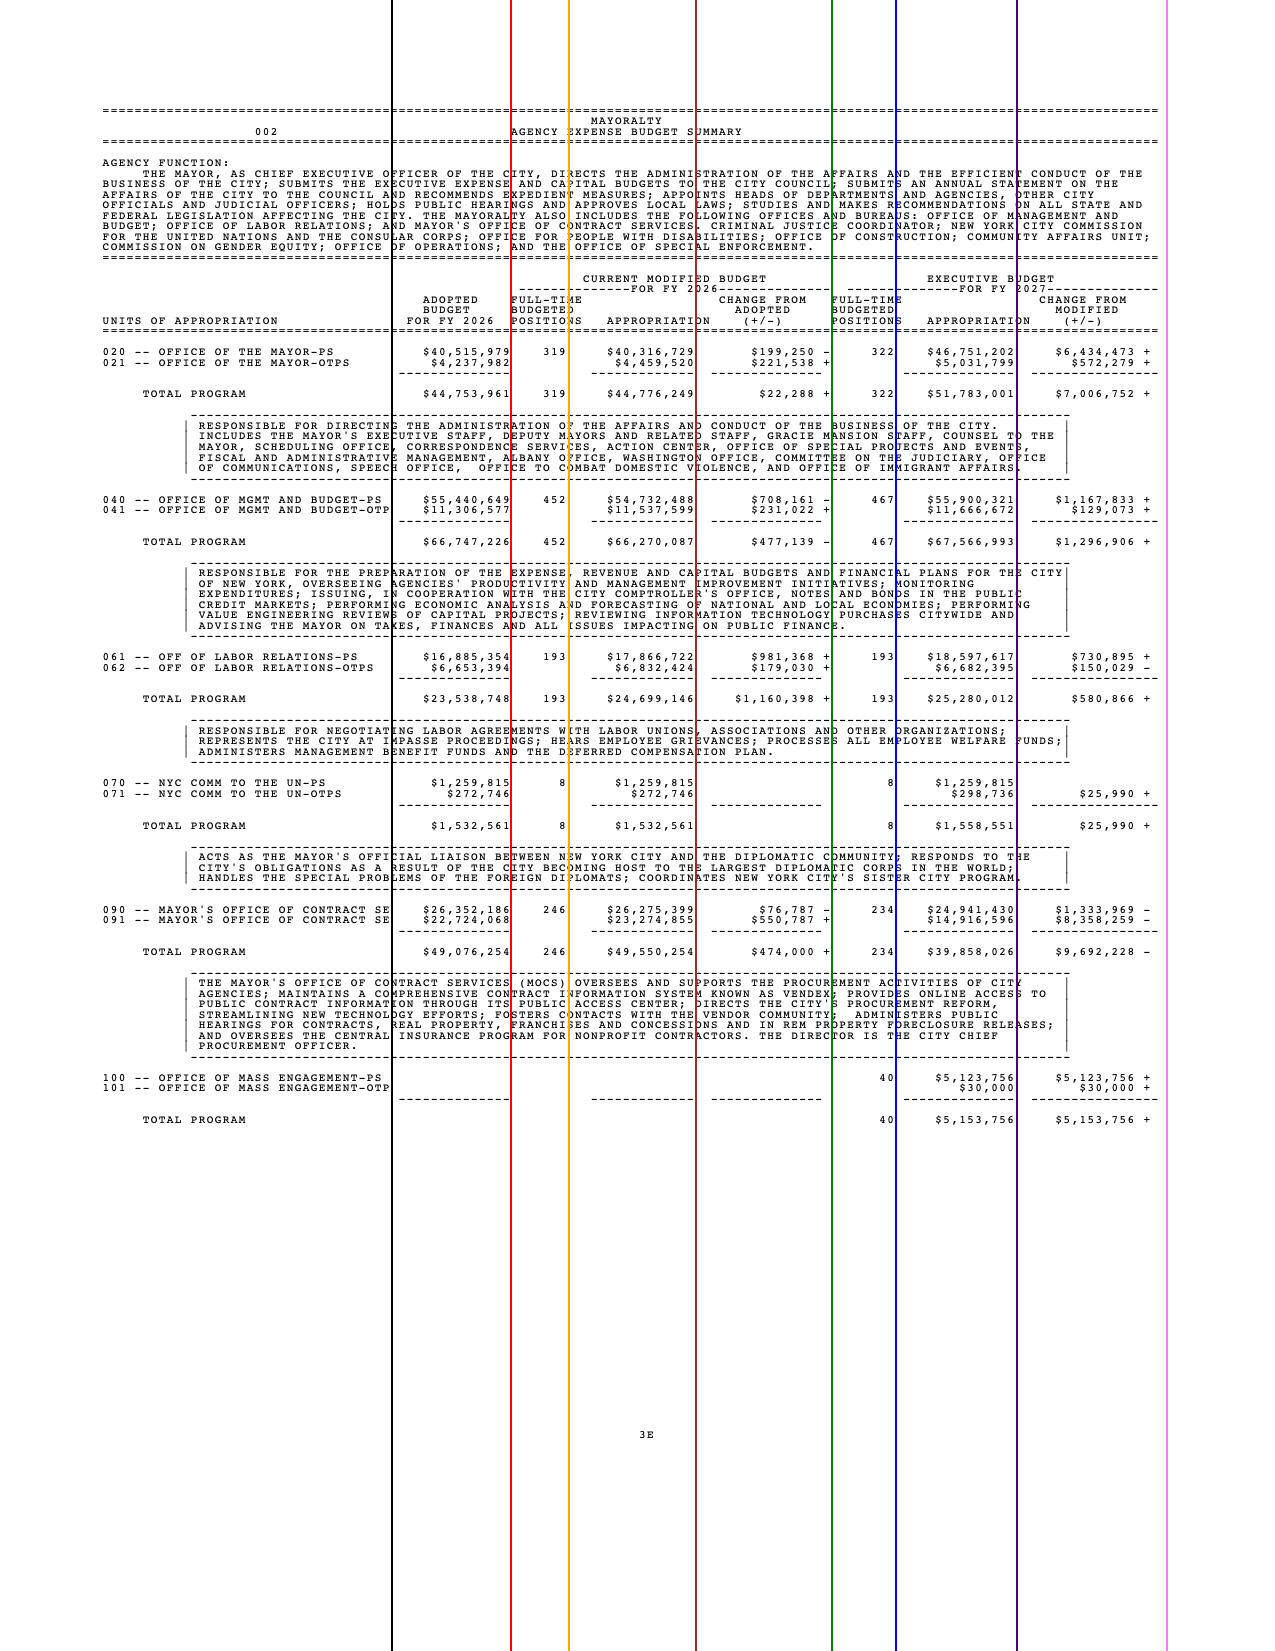

In [11]:
with pdfplumber.open(doc_path) as pdf:
    page = pdf.pages[5]
    im = page.to_image(resolution=150)
    for i,b in enumerate(HARDCODED_BOUNDARIES):
        im.draw_vline(b, stroke=COLORS[i], stroke_width=2)
    display(im.annotated)

In [12]:
# page_list = [5,6,7,8,12,13,14,15]


parsed_data = []

# Ensure doc_path points to your PDF file

# p_count = 3 # First budget summary is page 3E
with pdfplumber.open(doc_path) as pdf:
    visualize = False 
    
    # for page_num in tqdm(range(5,20)):
    for page in tqdm(pdf.pages):
        # print(p_count)
        page_num = page.page_number - 1 # convert pdf 1-indexing to python 0-indexing
        # print(page_num)
        
        # page = pdf.pages[page_num]
        
        page_data = []
        
        # ==========================================
        #           AGENCY EXTRACTION
        # ==========================================
        
        agency_data = extract_agency(doc_path, page_number = page_num)
        if visualize:
            print(f"agency_data: {agency_data}")
        
        # Skip if not an AGENCY EXPENSE BUDGET SUMMARY page
        if len(agency_data) == 0:
            # if visualize:
            print(f"SKIP PAGE: {page_num} -> {page_num-2}E")
            continue
        
        agency_name = agency_data[0][0]
        agency_number = agency_data[0][1]
        
        if visualize:
            print(f"agency_name: {agency_name}")
            print(f"agency_number: {agency_number}")
        
        # ==========================================
        #  UoA EXTRACTION LOGIC WITH VISUALIZATION
        # ==========================================
        # Matches "100 -- Name"
        UoA_pattern = re.compile(
            r"(?:(\d{3}|LESS)\s--\s([A-Za-z0-9_&\-'\s]+?)(?=\d|\s*\$|\s*$))", 
            re.IGNORECASE
        )
        UoA_matches = page.search(UoA_pattern)
        
        # Matches financial amounts or standalone headcounts
        fund_pattern = re.compile(r"\$?[0-9,]+(?: [+-])?", re.IGNORECASE)
        fund_matches = page.search(fund_pattern)
        

        if visualize:
            im = page.to_image(resolution=150)
            # Draw your vertical hardcoded column lines in blue
            im.draw_vlines(HARDCODED_BOUNDARIES, stroke="blue", stroke_width=1)
        
        for row in UoA_matches:
            if row['groups'][0]:
                UoA_code = row['groups'][0]
                raw_name = row['groups'][1]
            
            # --- 2. DRAW EACH MATCHED ROW ONTO THE IMAGE ---
            if visualize:
                # Draw a green box around the exact text matched by the regex
                im.draw_rect((row['x0'], row['top'], row['x1'], row['bottom']), stroke="green", stroke_width=1)
                
                # Draw a magenta alignment line all the way across the page. 
                # This visualizes the central "axis" used to grab numbers within the 5-point tolerance.
                # im.draw_line(((0, row['top']-2), (page.width, row['top']-2)), stroke="blue", stroke_width=1)
                im.draw_line(((0, row['top']), (page.width, row['top'])), stroke="magenta", stroke_width=1)
                # im.draw_line(((0, row['top']+2), (page.width, row['top']+2)), stroke="orange", stroke_width=1)
                
            
            # Initialize default row data dictionary
            row_data = {
                "Page": f"{page_num-2}E",
                "Agency": agency_name,
                "Agency Code": agency_number,
                "UoA Code": UoA_code,
                "UoA Name": raw_name,  
                "FY2026 Adopted Budget": "$0",
                "FY2026 Modified Full-Time Positions": "0",
                "FY2026 Modified Appropriation": "$0",
                "FY2026 Modified Change from Adopted": "$0",  
                "FY2027 Executive Full-Time Positions": "0",
                "FY2027 Executive Appropriation": "$0",
                "FY2027 Executive Change from Modified": "$0",
            }
            
            # Gather all numbers on the same horizontal plane (+/- 5 points) as the row text
            row_funds = [f for f in fund_matches if abs(f['top'] - row['top']) <= 2.0]
            
            for fund in row_funds:
                if visualize:
                    im.draw_rect((fund['x0'], fund['top'], fund['x1'], fund['bottom']), stroke="green", stroke_width=1)
                
                column_name = assign_to_column(fund['x0'], HARDCODED_BOUNDARIES)
                if column_name in row_data:
                    row_data[column_name] = fund['text']
                    
            page_data.append(row_data)
            
        if visualize:
            page_df = pd.DataFrame(page_data)
            print(page_df)
        
        parsed_data.extend(page_data)

        # p_count += 1        

        # --- 3. RENDER THE COMBINED ANNOTATIONS ---
        if visualize:
            display(im.annotated)

# Convert arrays into structured Pandas DataFrame output
final_df = pd.DataFrame(parsed_data)
final_df

  0%|          | 0/417 [00:00<?, ?it/s]

SKIP PAGE: 0 -> -2E
SKIP PAGE: 1 -> -1E
SKIP PAGE: 2 -> 0E
SKIP PAGE: 3 -> 1E
SKIP PAGE: 4 -> 2E
SKIP PAGE: 8 -> 6E
SKIP PAGE: 9 -> 7E
SKIP PAGE: 10 -> 8E
SKIP PAGE: 11 -> 9E
SKIP PAGE: 12 -> 10E
SKIP PAGE: 14 -> 12E
SKIP PAGE: 16 -> 14E
SKIP PAGE: 18 -> 16E
SKIP PAGE: 20 -> 18E
SKIP PAGE: 22 -> 20E
SKIP PAGE: 24 -> 22E
SKIP PAGE: 26 -> 24E
SKIP PAGE: 28 -> 26E
SKIP PAGE: 30 -> 28E
SKIP PAGE: 31 -> 29E
SKIP PAGE: 32 -> 30E
SKIP PAGE: 34 -> 32E
SKIP PAGE: 36 -> 34E
SKIP PAGE: 38 -> 36E
SKIP PAGE: 40 -> 38E
SKIP PAGE: 41 -> 39E
SKIP PAGE: 43 -> 41E
SKIP PAGE: 44 -> 42E
SKIP PAGE: 46 -> 44E
SKIP PAGE: 48 -> 46E
SKIP PAGE: 49 -> 47E
SKIP PAGE: 51 -> 49E
SKIP PAGE: 53 -> 51E
SKIP PAGE: 57 -> 55E
SKIP PAGE: 58 -> 56E
SKIP PAGE: 59 -> 57E
SKIP PAGE: 60 -> 58E
SKIP PAGE: 61 -> 59E
SKIP PAGE: 62 -> 60E
SKIP PAGE: 63 -> 61E
SKIP PAGE: 64 -> 62E
SKIP PAGE: 65 -> 63E
SKIP PAGE: 66 -> 64E
SKIP PAGE: 68 -> 66E
SKIP PAGE: 69 -> 67E
SKIP PAGE: 71 -> 69E
SKIP PAGE: 75 -> 73E
SKIP PAGE: 76 -> 74E
SKIP P

,Page,Agency,Agency Code,UoA Code,UoA Name,FY2026 Adopted Budget,FY2026 Modified Full-Time Positions,FY2026 Modified Appropriation,FY2026 Modified Change from Adopted,FY2027 Executive Full-Time Positions,FY2027 Executive Appropriation,FY2027 Executive Change from Modified
0,3E,MAYORALTY,002,020,OFFICE OF THE MAYOR-PS,"$40,515,979",319,"$40,316,729","$199,250 -",322,"$46,751,202","$6,434,473 +"
1,3E,MAYORALTY,002,021,OFFICE OF THE MAYOR-OTPS,"$4,237,982",0,"$4,459,520","$221,538 +",0,"$5,031,799","$572,279 +"
2,3E,MAYORALTY,002,040,OFFICE OF MGMT AND BUDGET-PS,"$55,440,649",452,"$54,732,488","$708,161 -",467,"$55,900,321","$1,167,833 +"
3,3E,MAYORALTY,002,041,OFFICE OF MGMT AND BUDGET-OTP,"$11,306,577",0,"$11,537,599","$231,022 +",0,"$11,666,672","$129,073 +"
4,3E,MAYORALTY,002,061,OFF OF LABOR RELATIONS-PS,"$16,885,354",193,"$17,866,722","$981,368 +",193,"$18,597,617","$730,895 +"
...,...,...,...,...,...,...,...,...,...,...,...,...
729,409E,PUBLIC ADMINISTRATOR-KINGS COUNTY,943,002,OTHER THAN PERSONAL SERVICES,"$49,136",0,"$49,136",$0,0,"$55,013","$5,877 +"
730,411E,PUBLIC ADMINISTRATOR- QUEENS COUNTY,944,001,PERSONAL SERVICES,"$678,895",8,"$673,895","$5,000 -",8,"$685,873","$11,978 +"
731,411E,PUBLIC ADMINISTRATOR- QUEENS COUNTY,944,002,OTHER THAN PERSONAL SERVICES,"$15,713",0,"$20,713","$5,000 +",0,"$15,713","$5,000 -"
732,413E,PUBLIC ADMINISTRATOR-RICHMOND COUNTY,945,001,PERSONAL SERVICES,"$617,545",5,"$617,545",$0,5,"$622,523","$4,978 +"


## Save data


In [ ]:
# final_df.to_csv(f"27_exec_UoA_v{VERSION}.csv", index=False)

In [18]:
target_cols = ["Agency Code","Agency", "Page"]

agencies = final_df.drop_duplicates(subset=["Agency Code"],keep="first")[target_cols]

agencies.sort_values("Agency Code")
agencies.to_csv(f"27_exec_agencies_v{VERSION}.csv", index=False)
agencies

,Agency Code,Agency,Page
0,002,MAYORALTY,3E
23,003,BOARD OF ELECTIONS,11E
25,004,CAMPAIGN FINANCE BOARD,13E
28,008,OFFICE OF THE ACTUARY,15E
30,010,BOROUGH PRESIDENT - MANHATTAN,17E
...,...,...,...
724,941,PUBLIC ADMINISTRATOR-NEW YORK COUNTY,405E
726,942,PUBLIC ADMINISTRATOR-BRONX COUNTY,407E
728,943,PUBLIC ADMINISTRATOR-KINGS COUNTY,409E
730,944,PUBLIC ADMINISTRATOR- QUEENS COUNTY,411E


## Analysis (if any)


In [14]:
final_df

,Page,Agency,Agency Code,UoA Code,UoA Name,FY2026 Adopted Budget,FY2026 Modified Full-Time Positions,FY2026 Modified Appropriation,FY2026 Modified Change from Adopted,FY2027 Executive Full-Time Positions,FY2027 Executive Appropriation,FY2027 Executive Change from Modified
0,3E,MAYORALTY,002,020,OFFICE OF THE MAYOR-PS,"$40,515,979",319,"$40,316,729","$199,250 -",322,"$46,751,202","$6,434,473 +"
1,3E,MAYORALTY,002,021,OFFICE OF THE MAYOR-OTPS,"$4,237,982",0,"$4,459,520","$221,538 +",0,"$5,031,799","$572,279 +"
2,3E,MAYORALTY,002,040,OFFICE OF MGMT AND BUDGET-PS,"$55,440,649",452,"$54,732,488","$708,161 -",467,"$55,900,321","$1,167,833 +"
3,3E,MAYORALTY,002,041,OFFICE OF MGMT AND BUDGET-OTP,"$11,306,577",0,"$11,537,599","$231,022 +",0,"$11,666,672","$129,073 +"
4,3E,MAYORALTY,002,061,OFF OF LABOR RELATIONS-PS,"$16,885,354",193,"$17,866,722","$981,368 +",193,"$18,597,617","$730,895 +"
...,...,...,...,...,...,...,...,...,...,...,...,...
729,409E,PUBLIC ADMINISTRATOR-KINGS COUNTY,943,002,OTHER THAN PERSONAL SERVICES,"$49,136",0,"$49,136",$0,0,"$55,013","$5,877 +"
730,411E,PUBLIC ADMINISTRATOR- QUEENS COUNTY,944,001,PERSONAL SERVICES,"$678,895",8,"$673,895","$5,000 -",8,"$685,873","$11,978 +"
731,411E,PUBLIC ADMINISTRATOR- QUEENS COUNTY,944,002,OTHER THAN PERSONAL SERVICES,"$15,713",0,"$20,713","$5,000 +",0,"$15,713","$5,000 -"
732,413E,PUBLIC ADMINISTRATOR-RICHMOND COUNTY,945,001,PERSONAL SERVICES,"$617,545",5,"$617,545",$0,5,"$622,523","$4,978 +"
